<a href="https://colab.research.google.com/github/anirudv/pfizer-supply-chain/blob/main/Anirud_Extracting_Dates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup environment and imports
!pip install pymupdf
from google.colab import files
import fitz

# Upload lender fees worksheet
uploaded = files.upload()

Saving sample-sdf-document.pdf to sample-sdf-document.pdf


In [ ]:
doc = fitz.open("sample-sdf-document.pdf")

print(f"Pages: {doc.page_count}\nPDF Metadata: {doc.metadata}")

Pages: 3
PDF Metadata: {'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': '', 'producer': '', 'creationDate': '', 'modDate': '', 'trapped': '', 'encryption': None}


In [ ]:
page = doc[0]
text = page.get_text("text")
print(text)

Cytiva
100 Results Way
Marlborough, MA 01752
United States
Page 1 / 1
cytiva.com
3 June, 2022
Re: ÄKTATM ready Flow Kit Storage Conditions
To Whom It May Concern,
The recommended storage temperature for standard ÄKTA ready flow kits is provided in Section 8.3 of the Operating 
Instructions 28960345 and specified as > +5 C. This recommendation also applies to all modified ÄKTA ready flow kits 
as well, including the two listed in the below table. Extended storage below the recommended +5
could lead to 
brittleness or cracking of the plastic connectors. However, the operating temperature of ÄKTA ready flow kits is +2 C to 
+40 C. If the kits are allowed to acclimate to a warmer temperature before being used this would reduce the risk of
damage to the kit during setup and handling.
Description
Part Number
Operating Temperature
High Flow Kit F, Modified, ÄKTA ready
29477427
+2 C to +40 C
High Flow Gradient C, Modified, ÄKTA ready
29184612
+2 C to +40 C
Operating Instructions access link:
h


=================== PAGE 1 ===================
✓ Extracted 'Vendor Name': 'Cytiva' | bbox: [547.4, 87.6, 576.0, 98.4]


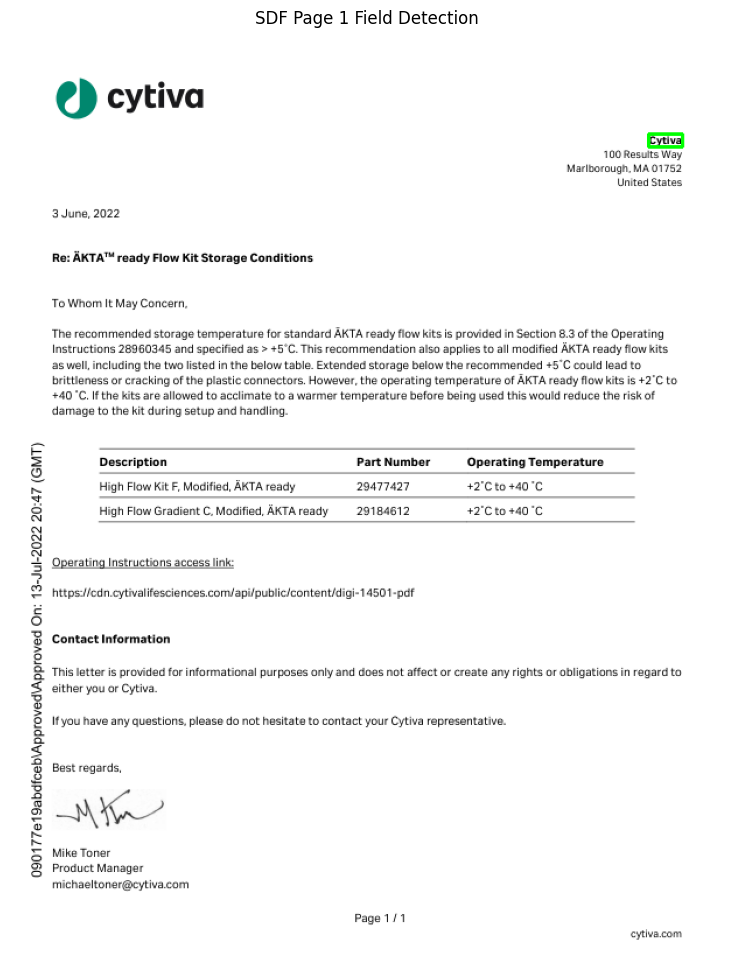


=================== PAGE 2 ===================
✓ Extracted 'Lot Number': '17242818' | bbox: [53.6, 110.5, 148.4, 122.7]
✓ Extracted 'Mfg Date': '20210126' | bbox: [53.6, 132.1, 188.3, 144.3]
✓ Extracted 'Exp Date': '20230126' | bbox: [53.6, 153.7, 165.8, 165.9]


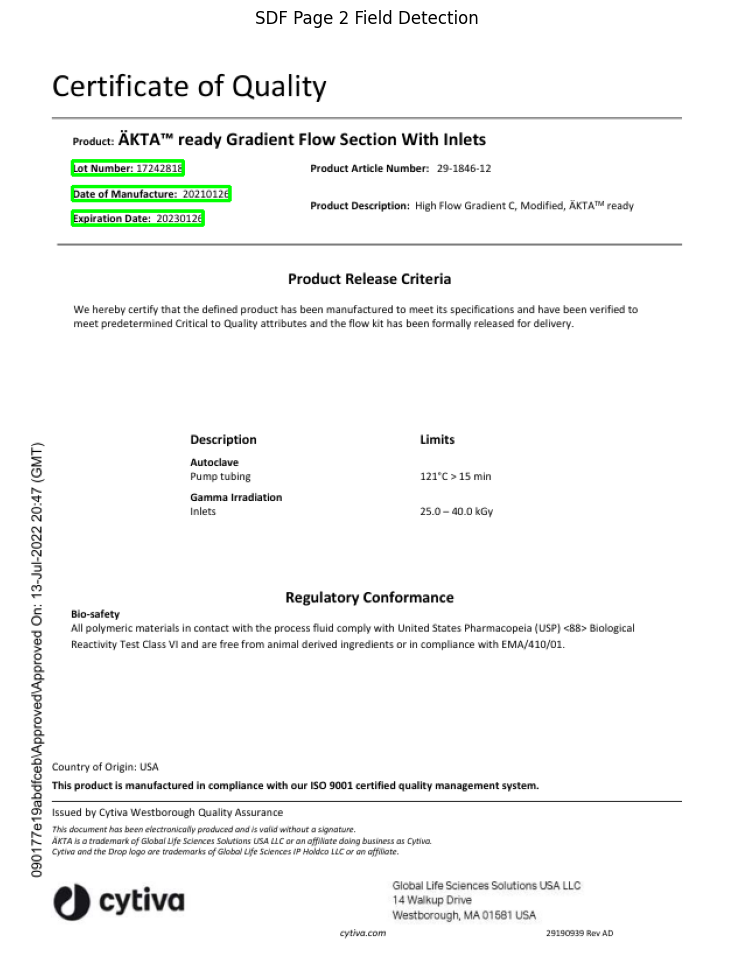


=================== PAGE 3 ===================
✓ Extracted 'Vendor Name': 'Cytiva' | bbox: [480.0, 22.8, 524.4, 44.8]
✓ Extracted 'Lot Number': '18356721' | bbox: [200.0, 167.2, 244.5, 181.0]
✓ Extracted 'Mfg Date': '20240315' | bbox: [200.0, 203.2, 244.5, 217.0]
✓ Extracted 'Exp Date': '20260315' | bbox: [200.0, 239.2, 244.5, 253.0]


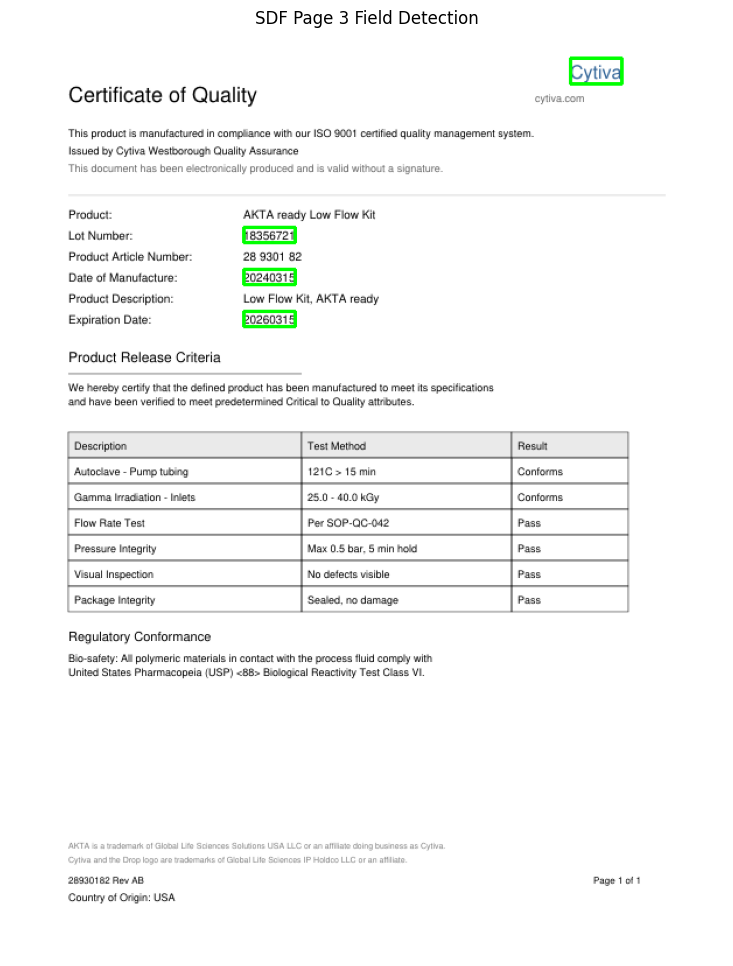

In [ ]:
import fitz
import cv2
import numpy as np
from PIL import Image
import re
import matplotlib.pyplot as plt
from collections import defaultdict


doc = fitz.open("sample-sdf-document.pdf")


def extract_field(pattern, text):
    match = re.search(pattern, text, re.IGNORECASE)
    return match.group(1).strip() if match else None


for page_num in range(len(doc)):
    page = doc[page_num]


    pix = page.get_pixmap()
    img = np.array(Image.frombytes("RGB", [pix.width, pix.height], pix.samples))


    full_text = page.get_text("text")
    words = page.get_text("words")  # [x0, y0, x1, y1, text, block, line, word_no]


    data = {
        "Vendor Name": extract_field(r"^(Cytiva)", full_text),
        "Lot Number": extract_field(r"Lot Number:\s*\n?\s*(\d+)", full_text),
        "Mfg Date": extract_field(r"Date of Manufacture:\s*\n?\s*(\d{8})", full_text),
        "Exp Date": extract_field(r"Expiration Date:\s*\n?\s*(\d{8})", full_text)
    }


    lines = defaultdict(list)
    for word in words:
        x0, y0, x1, y1, text, block, line, word_no = word
        lines[(block, line)].append((text, x0, y0, x1, y1))

    print(f"\n=================== PAGE {page_num + 1} ===================")


    for label, value in data.items():
        if not value:
            continue

        found = False
        for key, word_list in lines.items():
            combined_text = " ".join(w[0] for w in word_list)
            if value in combined_text:
                x0 = min(w[1] for w in word_list)
                y0 = min(w[2] for w in word_list)
                x1 = max(w[3] for w in word_list)
                y1 = max(w[4] for w in word_list)


                cv2.rectangle(img, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 2)
                print(f"✓ Extracted '{label}': '{value}' | bbox: [{x0:.1f}, {y0:.1f}, {x1:.1f}, {y1:.1f}]")
                found = True
                break


    plt.figure(figsize=(10, 12))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"SDF Page {page_num + 1} Field Detection")
    plt.show()